<a name="top" id="top"></a>

<div align="center">
    <h1>Stochastic Optimization</h1>
    <a href="https://www.linkedin.com/in/saikart/">Sai Karthik</a>
    <br>
    <i>Weldon School of Biomedical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/parkyr">Yirang Park</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/Pharma-optimization-flowsheet/blob/main/Enhanced_model/Pharma_Optimizer.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# What is this notebook about?

Imagine you run a pharmaceutical company and your job is to get a finished drug into the hands of patients. Making that drug isn't a single step — it's a chain of them. First someone has to synthesize the raw active ingredient, then someone has to formulate it into pills or vials, and finally someone has to package it and ship it out. For each of these steps, there are usually several different factories (**vendors**) you could hire, each with its own price, its own production capacity, and its own shipping cost to the next factory in the chain.

So the question is: **which factory should you pick at each step to get the drug made as cheaply as possible?**

That sounds straightforward — just pick the cheapest one at every stage — except for one big wrinkle: **you don't actually know how much drug patients are going to need.** Demand could come in low, it could come in normal, or a flu season or new diagnosis guideline could send it through the roof. And here's the catch: you have to sign contracts with vendors *before* you know what demand looks like. If you lock in tiny, cheap factories and demand spikes, you can't make enough drug and patients go without — which is both a public-health disaster and financially costly (shortage penalties, lost sales, regulatory issues). If you over-commit to huge expensive factories and demand stays low, you've wasted money.

This notebook solves exactly that problem using a technique called **two-stage stochastic optimization**:

- **Stage 1 (decide now, before you know demand):** pick which vendor to use at each manufacturing step, and which transportation routes to set up between them.
- **Stage 2 (react later, after demand is revealed):** decide how much to actually produce and ship through the supply chain you already committed to, and accept a penalty for any demand you can't meet.

Instead of optimizing for one guess at what demand will be, the model considers a whole range of possible demand **scenarios** (low, normal, high, or many samples drawn from a statistical distribution), each with its own probability. It then finds the supply chain design that minimizes the **expected total cost** — production + transport + shortage penalties — averaged across all those possible futures. This way you get a plan that is robust: it doesn't just work in the best case, it works reasonably well across everything that might actually happen.

The rest of the notebook walks through generating the vendor data, building the demand scenarios, solving the stochastic optimization problem, and visualizing the chosen supply-chain path.

# Introduction

This notebook extends the deterministic model to handle **demand uncertainty** using two-stage stochastic programming, solved via **[mpi-sppy](https://github.com/Pyomo/mpi-sppy)**.

## Mathematical Formulation

### Sets

| Symbol | Definition |
|--------|------------|
| $\mathcal{S}$ | Set of manufacturing steps (echelons), indexed by $s$ (e.g., API synthesis, formulation, fill/finish) |
| $\mathcal{V}_s$ | Set of candidate vendors for step $s$, indexed by $v$ |
| $\mathcal{R}$ | Set of transport routes between consecutive steps; each route is a tuple $(s_1, v_1, s_2, v_2)$ connecting vendor $v_1$ at step $s_1$ to vendor $v_2$ at step $s_2$ |
| $\Omega$ | Set of demand scenarios, indexed by $\omega$ |

### Parameters

| Symbol | Definition | Units |
|--------|------------|-------|
| $c_{s,v}$ | Production cost of vendor $v$ at step $s$ | \$/batch |
| $q_{s,v}$ | Production capacity of vendor $v$ at step $s$ | units |
| $t_{s_1,v_1,s_2,v_2}$ | Transportation cost for route $(s_1,v_1,s_2,v_2) \in \mathcal{R}$ | \$ |
| $d_\omega$ | Demand realization in scenario $\omega$ | units |
| $p_\omega$ | Probability of scenario $\omega$, with $\sum_{\omega \in \Omega} p_\omega = 1$ | — |
| $\rho$ | Shortage penalty cost per unit of unmet demand | \$/unit |

### Decision Variables

**First-stage (here-and-now) — decided before demand is revealed:**

| Variable | Domain | Definition |
|----------|--------|------------|
| $x_{s,v}$ | Binary $\{0,1\}$ | $= 1$ if vendor $v$ is selected at step $s$, 0 otherwise |
| $y_{s_1,v_1,s_2,v_2}$ | Binary $\{0,1\}$ | $= 1$ if transport route $(s_1,v_1,s_2,v_2)$ is selected, 0 otherwise |

**Second-stage (wait-and-see) — determined after demand $d_\omega$ is observed:**

| Variable | Domain | Definition |
|----------|--------|------------|
| $f_{s}^{\omega}$ | Continuous $\geq 0$ | Material flow (throughput) at step $s$ in scenario $\omega$ |
| $u_{\omega}$ | Continuous $\geq 0$ | Unmet demand (shortage) in scenario $\omega$ |

### Objective

Minimize the expected total cost (production + transport + shortage penalty) across all scenarios:

$$\min \; \sum_{s \in \mathcal{S}} \sum_{v \in \mathcal{V}_s} c_{s,v} \, x_{s,v} \;+\; \sum_{(s_1,v_1,s_2,v_2) \in \mathcal{R}} t_{s_1,v_1,s_2,v_2} \, y_{s_1,v_1,s_2,v_2} \;+\; \sum_{\omega \in \Omega} p_\omega \, \rho \, u_\omega$$

### Constraints

**First-stage constraints (scenario-independent):**

1. **One vendor per step:** Exactly one vendor must be selected at each manufacturing step.
$$\sum_{v \in \mathcal{V}_s} x_{s,v} = 1 \qquad \forall \, s \in \mathcal{S}$$

2. **One transport route per step pair:** Exactly one route connects each pair of consecutive steps.
$$\sum_{\substack{(s_1,v_1,s_2,v_2) \in \mathcal{R} \\ s_1 = s,\; s_2 = s'}} y_{s_1,v_1,s_2,v_2} = 1 \qquad \forall \, (s, s') \text{ consecutive in } \mathcal{S}$$

3. **Route–vendor linking:** A transport route can only be selected if both its source and destination vendors are selected.
$$y_{s_1,v_1,s_2,v_2} \leq x_{s_1,v_1} \qquad \forall \, (s_1,v_1,s_2,v_2) \in \mathcal{R}$$
$$y_{s_1,v_1,s_2,v_2} \leq x_{s_2,v_2} \qquad \forall \, (s_1,v_1,s_2,v_2) \in \mathcal{R}$$

**Second-stage constraints (per scenario $\omega$):**

4. **Step capacity:** Flow at each step cannot exceed the selected vendor's capacity.
$$f_s^{\omega} \leq \sum_{v \in \mathcal{V}_s} q_{s,v} \, x_{s,v} \qquad \forall \, s \in \mathcal{S}, \; \forall \, \omega \in \Omega$$

5. **Flow conservation:** Material flow is non-increasing across consecutive steps (serial supply chain — no inventory buildup between echelons).
$$f_{s'}^{\omega} \leq f_{s}^{\omega} \qquad \forall \, (s, s') \text{ consecutive in } \mathcal{S}, \; \forall \, \omega \in \Omega$$

6. **Demand satisfaction:** At the final step $s_{\text{last}}$, throughput plus shortage must meet demand.
$$f_{s_{\text{last}}}^{\omega} + u_\omega \geq d_\omega \qquad \forall \, \omega \in \Omega$$

## mpi-sppy Architecture

The stochastic model is built using the **mpi-sppy scenario creator pattern**:

1. `pharma_scenario_creator(scenario_name, **kwargs)` — builds a Pyomo `ConcreteModel` for a **single** scenario and annotates it with `attach_root_node` to mark non-anticipativity variables ($x$, $y$)
2. `ExtensiveForm` — assembles all scenario sub-models into the deterministic equivalent and solves exactly
3. `PH` (Progressive Hedging) — Lagrangian decomposition over scenarios; scales to large scenario sets

# Setup and Imports

In [3]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Install Python packages (works in both Colab and local Jupyter)
%pip install -q pyomo mpi-sppy highspy networkx

# Colab-only system dependencies
if IN_COLAB:
    !apt-get install -y -qq glpk-utils
    !sudo apt-get install -y graphviz graphviz-dev

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import sys                                                                    
sys.path.insert(0, "Enhanced_model")

from pharma_optimizer import (
    Generator,
    DemandScenarioGenerator,
    StochasticProductionOptimizer,
    visualize_solution_from_optimizer,
    visualize_scenarios,
)

# Data Generation

Generate random manufacturing and transportation data.

In [5]:
# Generate a 3-step, 3-vendor instance
generator = Generator(steps=3, options=3)
generator.createManufacturingData()
generator.createTransportData()

# Display data
prod_df = pd.read_csv("manufacturingData2.csv")
print("Production Data:")
print(prod_df)

Production Data:
   step Vendor  Production   Cost
0     1      A       68349  16655
1     1      B       20182  16100
2     1      C       75488  99211
3     2      A       61725  86718
4     2      B       17231  27418
5     2      C       92257  71737
6     3      A       38345  57797
7     3      B       70214  93352
8     3      C       46256  47783


# Demand Scenario Generation

The demand-scenario constructions used here follow Thevenin, Adulyasak, and Cordeau (2021), *"Material Requirements Planning Under Demand Uncertainty Using Stochastic Optimization"*, *Production and Operations Management* **30**(2): 475–493 ([doi:10.1111/poms.13277](https://doi.org/10.1111/poms.13277)). In that paper, demand over the planning horizon is represented by probability distributions (non-stationary Normal for classical items, Poisson for slow-moving items, and zero-inflated Poisson for lumpy demand) which are then sampled into a finite set of scenarios to drive the stochastic optimization.

The `DemandScenarioGenerator` class creates demand scenarios using:
1. **Discrete scenarios**: Low/Base/High demand levels with specified probabilities
2. **Truncated Normal**: Sampled scenarios from a truncated normal distribution

## Demand Scaling Rationale

The mean demand must be set carefully relative to the vendor capacities in the data, otherwise all scenario results will be identical.

**Why results collapse to the same value:**

In this two-stage stochastic model, production and transport costs are **first-stage (fixed)** decisions — they are the same across all scenarios. The only scenario-dependent cost term is the **shortage penalty** (`penalty × unmet_demand`). If unmet demand is zero in every scenario, all total costs are equal.

There are two ways unmet demand stays zero even as demand increases:
1. All scenario demands are below the bottleneck capacity of the selected vendors.
2. The optimizer switches to higher-capacity vendors to avoid the shortage penalty — which it will always do when the penalty is large enough.

**The hard ceiling:** The maximum achievable bottleneck across *all* vendor combinations is constrained by the tightest step. In this dataset:

| Step | Best Vendor | Capacity |
|------|-------------|----------|
| 1    | C           | 97,240   |
| 2    | C           | 66,539   | ← binding constraint |
| 3    | C           | 77,239   |

No combination of vendors can sustain throughput above **66,539 units**.

**Fix:** Set `mean_demand = 55,000` so the high scenario demand (`1.3 × 55,000 = 71,500`) exceeds this ceiling. The optimizer *cannot* avoid a shortage in the high scenario regardless of vendor choice, forcing nonzero shortage costs and differentiating the scenario results.

In [6]:
# Create scenario generator with mean demand = 55000, CV = 20%
# Max achievable bottleneck across ALL vendor combinations is 66,539 (Step 2, Vendor C).
# High scenario (1.3x = 71,500) exceeds this, guaranteeing a shortage regardless of vendor choice.
scenario_gen = DemandScenarioGenerator(mean_demand=55000, cv=0.2, seed=42)

# Generate discrete Low/Base/High scenarios
discrete_scenarios = scenario_gen.generate_discrete_scenarios(
    levels=[0.8, 1.0, 1.3],
    probabilities=[0.2, 0.5, 0.3]
)

print("Discrete Scenarios:")
scenario_gen.summary(discrete_scenarios)

Discrete Scenarios:
=== DEMAND SCENARIOS ===
Scenario              Demand  Probability
----------------------------------------
low                 44000.00       20.00%
base                55000.00       50.00%
high                71500.00       30.00%
----------------------------------------
Expected demand: 57750.00
Std deviation:   9915.27
CV:              17.17%


In [7]:
# Generate scenarios from truncated normal distribution
normal_scenarios = scenario_gen.generate_normal_scenarios(num_scenarios=5)

print("\nTruncated Normal Scenarios:")
scenario_gen.summary(normal_scenarios)


Truncated Normal Scenarios:
=== DEMAND SCENARIOS ===
Scenario              Demand  Probability
----------------------------------------
scenario_1          40902.99       20.00%
scenario_2          49231.62       20.00%
scenario_3          55000.01       20.00%
scenario_4          60768.42       20.00%
scenario_5          69097.07       20.00%
----------------------------------------
Expected demand: 55000.02
Std deviation:   9633.30
CV:              17.52%


# Stochastic Optimization

Run the two-stage stochastic optimization with demand uncertainty.

In [8]:
# Create stochastic optimizer with discrete scenarios
stochastic_optimizer = StochasticProductionOptimizer(
    prod_cost_csv="manufacturingData2.csv",
    transport_cost_csv="transportData2.csv",
    scenarios=discrete_scenarios,
    shortage_penalty=1000.0
)

# Solve
result = stochastic_optimizer.solve(solver_name='glpk')
print(f"Solver status: {result.solver.termination_condition}\n")

# Display results
stochastic_optimizer.summary()

[    5.58] Initializing SPBase
Solver status: optimal

STATIC-DYNAMIC STOCHASTIC OPTIMIZATION RESULTS
(Multi-Echelon with Demand Uncertainty — via mpi-sppy)

--- FIRST-STAGE DECISIONS (Static) ---

Selected vendors by step:
  Step 1: C (Cost: $99,211, Capacity: 75,488)
  Step 2: C (Cost: $71,737, Capacity: 92,257)
  Step 3: B (Cost: $93,352, Capacity: 70,214)

Selected transport routes:
  Step 1(C) -> Step 2(C): $0
  Step 2(C) -> Step 3(B): $28

Optimal Path: Step 1(C) -> Step 2(C) -> Step 3(B)

--- MULTI-ECHELON THROUGHPUT ---
Per-step capacity of selected vendors:
  Step 1: 75,488
  Step 2: 92,257
  Step 3: 70,214 <-- BOTTLENECK

Effective throughput (bottleneck): 70,214

--- SECOND-STAGE RESULTS (Dynamic per Scenario) ---
scenario    demand  probability  bottleneck_capacity  throughput  unmet_demand  prod_cost  transport_cost  shortage_cost   total_cost
     low 44,000.00         0.20            70,214.00   44,000.00          0.00 264,300.00           28.00           0.00   264,328.

# Visualization

Visualize the optimal vendor selection path.

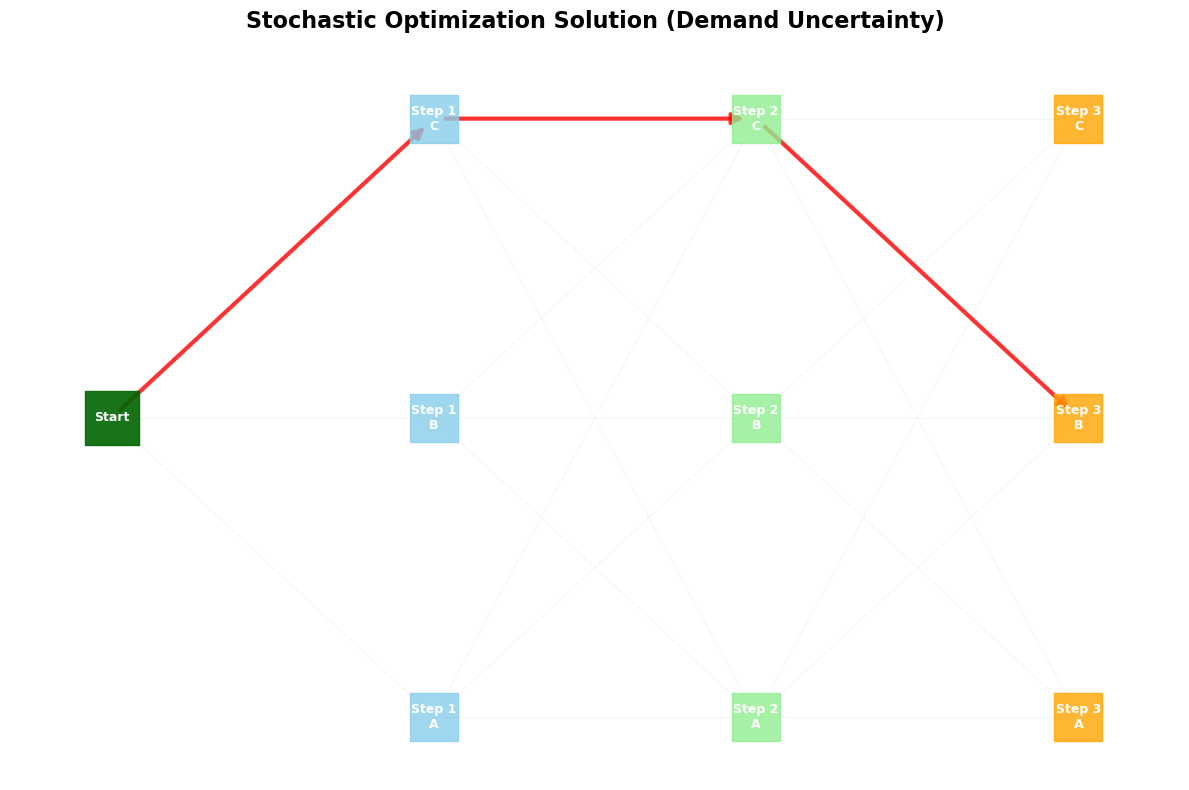

In [9]:
# Visualize the stochastic solution
G, pos, chosen_path = visualize_solution_from_optimizer(
    stochastic_optimizer,
    title="Stochastic Optimization Solution (Demand Uncertainty)"
)
plt.show()

# Scenario Analysis

Detailed analysis of results across different demand scenarios.

In [10]:
# Get detailed scenario results
scenario_df = stochastic_optimizer.get_scenario_results()
print("Scenario Results:")
print(scenario_df.to_string(index=False))

# Cost statistics
stats = stochastic_optimizer.get_cost_statistics()
print(f"\nExpected Cost: ${stats['expected_cost']:,.2f}")
print(f"Std Deviation: ${stats['std_dev']:,.2f}")
print(f"Cost Range: ${stats['min_cost']:,.2f} - ${stats['max_cost']:,.2f}")

Scenario Results:
scenario  demand  probability  bottleneck_capacity  throughput  unmet_demand  prod_cost  transport_cost  shortage_cost  total_cost
     low 44000.0          0.2              70214.0     44000.0           0.0   264300.0            28.0            0.0    264328.0
    base 55000.0          0.5              70214.0     55000.0           0.0   264300.0            28.0            0.0    264328.0
    high 71500.0          0.3              70214.0     70214.0        1286.0   264300.0            28.0      1286000.0   1550328.0

Expected Cost: $650,128.00
Std Deviation: $589,319.23
Cost Range: $264,328.00 - $1,550,328.00


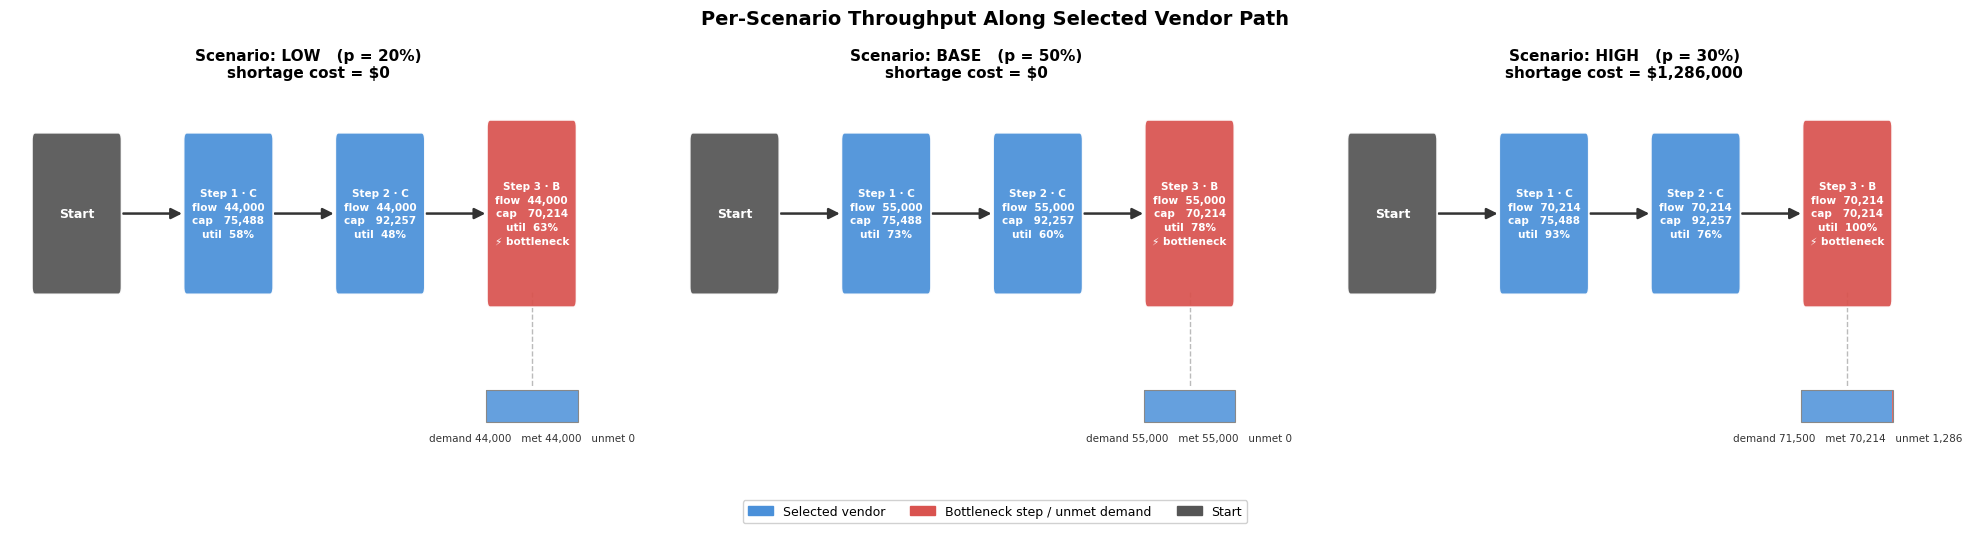

In [11]:
from pharma_optimizer import visualize_scenarios

visualize_scenarios(stochastic_optimizer)